In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
df=pd.read_csv("/kaggle/input/indian-startup-dataset/Indian Startup.csv")
df

,Company/Brand,Founded,Headquarters,Sector,What it does,Founder/s,Investor/s,Amount,Stage,Date
0,CollegeDekho,2015,Gurgaon,E-learning,"Collegedekho.com is Student’s Partner, Friend ...",Ruchir Arora,"Disrupt ADQ, QIC",35000000.0,Series B,Dec-21
1,BOX8,2012,Mumbai,Food & Beverages,India's Largest Desi Meals Brand,"Anshul Gupta, Amit Raj",Tiger Global,40000000.0,NaN,Dec-21
2,Simpl,2015,Bangalore,Consumer Services,Simpl empowers merchants to build trusted rela...,"Nitya, Chaitra Chidanand","Valar Ventures, IA Ventures",40000000.0,Series B,Dec-21
3,8i Ventures,2018,Mumbai,Venture Capital & Private Equity,8i is a Mumbai & Bangalore based early stage f...,Vikram Chachra,NaN,50000000.0,NaN,Dec-21
4,PayGlocal,2021,Bangalore,Financial Services,PayGlocal is a FinTech solving for global paym...,"Prachi Dharani, Rohit Sukhija, Yogesh Lokhande",Sequoia Capital India,4900000.0,Series A,Dec-21
...,...,...,...,...,...,...,...,...,...,...
1204,HobSpace,2019,Mumbai,EdTech,HobSpace is a platform for extra-curricular ac...,"Priya Goel Sheth, Harsh Jain","Siddharth Bhaskar Shah, Upsparks",100000.0,Pre-series A1,Jan-21
1205,DcodeAI,2020,New Delhi,EdTech,EMPOWER LEARNERS TO BE FUTURE READY USING AI,"Kartik Sharma, Ashish Aggarwal",S Chand,500000.0,NaN,Jan-21
1206,Biocon Biologics,1978,Bangalore,BioTechnology,Biocon is a fully integrated pure play biosimi...,Kiran Mazumdar-Shaw,"Goldman Sachs, Tata Capital",70000000.0,NaN,Jan-21
1207,KiranaKart,2020,Mumbai,E-commerce,A better model for instant grocery delivery in...,"Kaivalya Vohra, Aadit Palicha",Global Founders Capital,720000.0,Pre-seed,Jan-21


# Objectives:
1. To understand the start-up dynamics of India
2. Identify emerging sectors of business in India.
3. Identify preferred cities suitable for start-ups.  
4. Investments made in top most emerging business sectors.
5. Growth of startups since 1990.

In [3]:
df.isnull().sum()

Company/Brand      0
Founded            0
Headquarters       1
Sector             0
What it does       0
Founder/s          4
Investor/s        67
Amount             0
Stage            428
Date               0
dtype: int64

In [4]:
df.describe()

,Founded,Amount
count,1209.000000,1.209000e+03
mean,2016.656741,1.487555e+08
std,4.515660,4.313943e+09
min,1963.000000,0.000000e+00
25%,2015.000000,5.000000e+05
50%,2018.000000,2.300000e+06
75%,2020.000000,1.100000e+07
max,2021.000000,1.500000e+11


In [5]:
df.Amount.isna().sum()

0

In [6]:
#replacing "0" with mean value:
x=df['Amount'].mean()
x

148755510.33912325

In [7]:
df['Amount'].replace([0],x,inplace=True)
df

,Company/Brand,Founded,Headquarters,Sector,What it does,Founder/s,Investor/s,Amount,Stage,Date
0,CollegeDekho,2015,Gurgaon,E-learning,"Collegedekho.com is Student’s Partner, Friend ...",Ruchir Arora,"Disrupt ADQ, QIC",35000000.0,Series B,Dec-21
1,BOX8,2012,Mumbai,Food & Beverages,India's Largest Desi Meals Brand,"Anshul Gupta, Amit Raj",Tiger Global,40000000.0,NaN,Dec-21
2,Simpl,2015,Bangalore,Consumer Services,Simpl empowers merchants to build trusted rela...,"Nitya, Chaitra Chidanand","Valar Ventures, IA Ventures",40000000.0,Series B,Dec-21
3,8i Ventures,2018,Mumbai,Venture Capital & Private Equity,8i is a Mumbai & Bangalore based early stage f...,Vikram Chachra,NaN,50000000.0,NaN,Dec-21
4,PayGlocal,2021,Bangalore,Financial Services,PayGlocal is a FinTech solving for global paym...,"Prachi Dharani, Rohit Sukhija, Yogesh Lokhande",Sequoia Capital India,4900000.0,Series A,Dec-21
...,...,...,...,...,...,...,...,...,...,...
1204,HobSpace,2019,Mumbai,EdTech,HobSpace is a platform for extra-curricular ac...,"Priya Goel Sheth, Harsh Jain","Siddharth Bhaskar Shah, Upsparks",100000.0,Pre-series A1,Jan-21
1205,DcodeAI,2020,New Delhi,EdTech,EMPOWER LEARNERS TO BE FUTURE READY USING AI,"Kartik Sharma, Ashish Aggarwal",S Chand,500000.0,NaN,Jan-21
1206,Biocon Biologics,1978,Bangalore,BioTechnology,Biocon is a fully integrated pure play biosimi...,Kiran Mazumdar-Shaw,"Goldman Sachs, Tata Capital",70000000.0,NaN,Jan-21
1207,KiranaKart,2020,Mumbai,E-commerce,A better model for instant grocery delivery in...,"Kaivalya Vohra, Aadit Palicha",Global Founders Capital,720000.0,Pre-seed,Jan-21


In [8]:
#checking for values that are "0" in "Amount" column:
df[df['Amount']==0].value_counts().sum()

0

# Cities preferred by owners to operate their start-ups: 

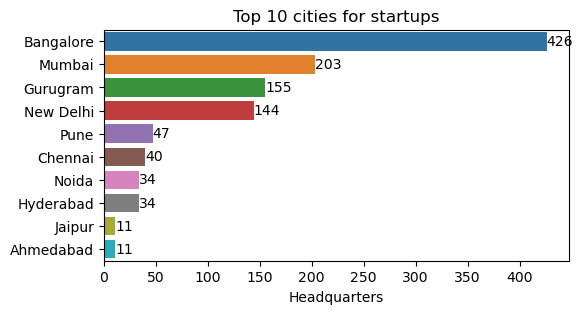

In [9]:
top_cities=pd.DataFrame(df['Headquarters'].value_counts().sort_values(ascending=False))
top_cities=top_cities.head(10)
plt.figure(figsize=(6,3))
axis=sns.barplot(x=top_cities['Headquarters'],y=top_cities.index)
axis.bar_label(axis.containers[0])
plt.title("Top 10 cities for startups")
plt.show()

# Emerging sectors of business: 

<function matplotlib.pyplot.show(close=None, block=None)>

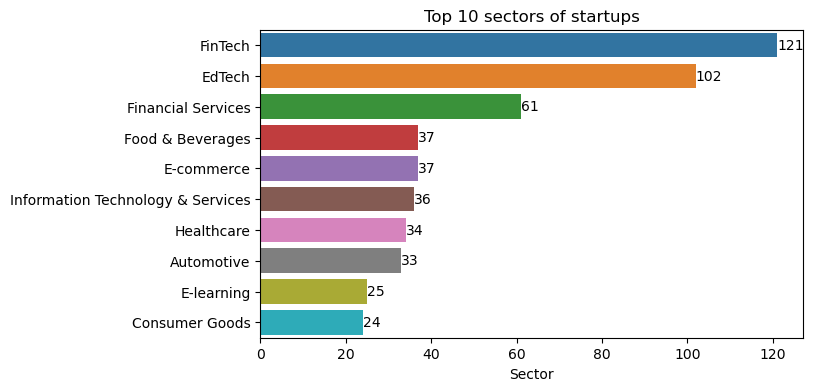

In [10]:
top_sector=pd.DataFrame(df["Sector"].value_counts().sort_values(ascending=False))
top_sector=top_sector.head(10)
plt.figure(figsize=(7,4))
axis=sns.barplot(x=top_sector['Sector'],y=top_sector.index)
axis.bar_label(axis.containers[0])
plt.title("Top 10 sectors of startups")
plt.show

In [11]:
df['Amount'].sort_values(ascending=False)

959     1.500000e+11
1096    1.000000e+09
170     8.400000e+08
939     8.000000e+08
642     6.600000e+08
            ...     
239     1.000000e+05
733     1.000000e+05
927     1.000000e+05
810     1.000000e+05
96      1.000000e+04
Name: Amount, Length: 1209, dtype: float64

In [12]:
df.columns

Index(['Company/Brand', 'Founded', 'Headquarters', 'Sector', 'What it does',
       'Founder/s', 'Investor/s', 'Amount', 'Stage', 'Date '],
      dtype='object')

In [13]:
df.rename(columns={"Date ":"current_date"},inplace=True)
df

,Company/Brand,Founded,Headquarters,Sector,What it does,Founder/s,Investor/s,Amount,Stage,current_date
0,CollegeDekho,2015,Gurgaon,E-learning,"Collegedekho.com is Student’s Partner, Friend ...",Ruchir Arora,"Disrupt ADQ, QIC",35000000.0,Series B,Dec-21
1,BOX8,2012,Mumbai,Food & Beverages,India's Largest Desi Meals Brand,"Anshul Gupta, Amit Raj",Tiger Global,40000000.0,NaN,Dec-21
2,Simpl,2015,Bangalore,Consumer Services,Simpl empowers merchants to build trusted rela...,"Nitya, Chaitra Chidanand","Valar Ventures, IA Ventures",40000000.0,Series B,Dec-21
3,8i Ventures,2018,Mumbai,Venture Capital & Private Equity,8i is a Mumbai & Bangalore based early stage f...,Vikram Chachra,NaN,50000000.0,NaN,Dec-21
4,PayGlocal,2021,Bangalore,Financial Services,PayGlocal is a FinTech solving for global paym...,"Prachi Dharani, Rohit Sukhija, Yogesh Lokhande",Sequoia Capital India,4900000.0,Series A,Dec-21
...,...,...,...,...,...,...,...,...,...,...
1204,HobSpace,2019,Mumbai,EdTech,HobSpace is a platform for extra-curricular ac...,"Priya Goel Sheth, Harsh Jain","Siddharth Bhaskar Shah, Upsparks",100000.0,Pre-series A1,Jan-21
1205,DcodeAI,2020,New Delhi,EdTech,EMPOWER LEARNERS TO BE FUTURE READY USING AI,"Kartik Sharma, Ashish Aggarwal",S Chand,500000.0,NaN,Jan-21
1206,Biocon Biologics,1978,Bangalore,BioTechnology,Biocon is a fully integrated pure play biosimi...,Kiran Mazumdar-Shaw,"Goldman Sachs, Tata Capital",70000000.0,NaN,Jan-21
1207,KiranaKart,2020,Mumbai,E-commerce,A better model for instant grocery delivery in...,"Kaivalya Vohra, Aadit Palicha",Global Founders Capital,720000.0,Pre-seed,Jan-21


# Highest investments made in popular Business Sectors:

In [14]:
df["Amount"].value_counts().sort_values(ascending=False)

1.487555e+08    145
1.000000e+06     87
2.000000e+06     60
3.000000e+06     48
1.000000e+07     43
               ... 
2.150000e+08      1
8.300000e+07      1
1.080000e+08      1
6.400000e+07      1
7.200000e+05      1
Name: Amount, Length: 198, dtype: int64

In [15]:
#top 10 emerging sectors of business:
df['Sector'].value_counts()[:10]

FinTech                              121
EdTech                               102
Financial Services                    61
Food & Beverages                      37
E-commerce                            37
Information Technology & Services     36
Healthcare                            34
Automotive                            33
E-learning                            25
Consumer Goods                        24
Name: Sector, dtype: int64

In [16]:
#grouping sectors in terms of investments made in those sectors:
df1=df.groupby(by='Sector').sum().drop("Founded",axis=1)
df1

/tmp/ipykernel_20/2258961992.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df1=df.groupby(by='Sector').sum().drop("Founded",axis=1)


,Amount
Sector,
AI Chatbot,7.500000e+06
AI company,1.537555e+08
AI startup,4.911665e+08
AR startup,3.000000e+05
Advertisement,1.800000e+06
...,...
Video communication,3.000000e+06
Water purification,1.600000e+06
Wholesale,3.500000e+06


In [17]:
#companies with top most investment:

In [18]:
df2=df1.sort_values(by='Amount',ascending=False)[:10].reset_index()

In [19]:
df2

,Sector,Amount
0,FinTech,1.545454e+11
1,EdTech,4.470374e+09
2,Automotive,2.650722e+09
3,Financial Services,2.149972e+09
4,Food & Beverages,1.662284e+09
5,E-commerce,1.626956e+09
6,Healthcare,1.472919e+09
7,HealthCare,1.090529e+09
8,Innovation Management,1.000000e+09
9,Sports,9.907555e+08


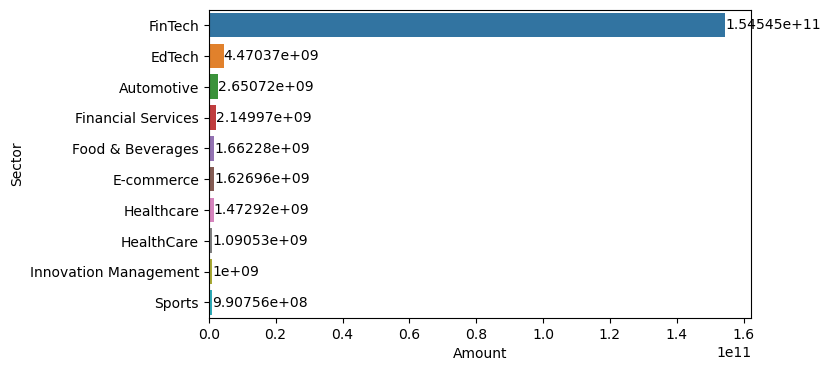

In [20]:
#visual representation of investments made in different sectors:
plt.figure(figsize=(7,4))
graph=sns.barplot(y=df2["Sector"], x=df2["Amount"])
graph.bar_label(graph.containers[0])
plt.show()


# Growth of startups since 1990:

<Axes: xlabel='Founded', ylabel='Count'>

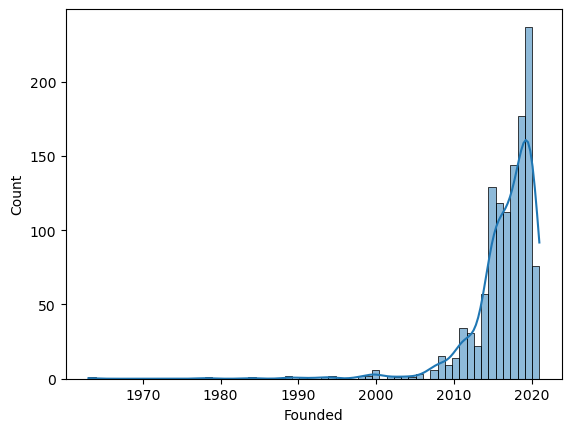

In [21]:
sns.histplot(df["Founded"], kde=True)

# Top investors:

In [22]:
top_investors= pd.DataFrame(df['Investor/s'].value_counts().sort_values(ascending = False))
top_investors=top_investors.head(10)


Text(0.5, 1.0, 'Top investors in start-ups')

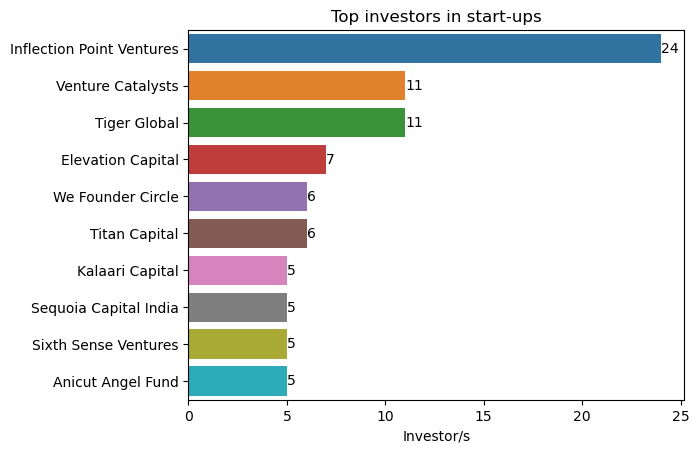

In [23]:
#visual:
invest=sns.barplot(x=top_investors['Investor/s'], y=top_investors.index)
invest.bar_label(invest.containers[0])
plt.title("Top investors in start-ups")


# CONCLUSION:
1. Top cities preferred by entrepreneurs for their business operations are Bangalore and Mumbai.
2. Top preferred sector for startup is 'Fintech' followed by Edtech.
3. Max investemnts are made in Fintech sector with "1."545454e+11" dollars.
4. Most startups came into existence in the year 2020.